# DINOv2 Zero-Shot Baseline (Dermoscope-Only)

Establishes a baseline using frozen DINOv2 features + logistic regression — no neural net training involved. This tells us how much useful info the pretrained representations already carry before we start fine-tuning anything.

We test both DINOv2-Base (ViT-B/14) and DINOv2-Small (ViT-S/14) to see if model size matters for zero-shot transfer on dermoscopy images.

**Binary labels:** Melanoma, BCC, SCC, Actinic Keratosis → Malignant (1) | Benign_or_Other → Benign (0)

## 1. Setup & Imports

In [ ]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, precision_recall_fscore_support, fbeta_score
)
from sklearn.preprocessing import StandardScaler

print("Imports complete.")

Imports complete.


In [ ]:
# ── Configuration ──
IMAGES_DIR = "../DataCleaning/Images"
MANIFEST_PATH = "../DataCleaning/instances.csv"
BATCH_SIZE = 32  # Larger batch for feature extraction (no backprop)
NUM_CLASSES = 2
SEED = 42

CLASS_NAMES = ["Benign", "Malignant"]
MIN_SENSITIVITY_TARGET = 0.95

# Logistic regression config
LR_MAX_ITER = 1000
LR_C = 1.0  # Regularization strength (inverse)
LR_CLASS_WEIGHT = 'balanced'  # Handle class imbalance

NUM_WORKERS = 0 if os.name == "nt" else min(os.cpu_count() or 8, 12)

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using: {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print(f"\n🔬 ZERO-SHOT BASELINE EXPERIMENT")
print(f"  • No neural network training — frozen DINOv2 features only")
print(f"  • Simple Logistic Regression classifier")
print(f"  • Compare: DINOv2-Base (ViT-B/14) vs DINOv2-Small (ViT-S/14)")
print(f"  • Same stratified splits as fine-tuned models (seed={SEED})")
print(f"  • Establishes lower-bound performance for comparison")

if torch.cuda.is_available():
    print(f"\nGPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using: cuda
PyTorch: 2.5.1+cu121

🔬 ZERO-SHOT BASELINE EXPERIMENT
  • No neural network training — frozen DINOv2 features only
  • Simple Logistic Regression classifier
  • Compare: DINOv2-Base (ViT-B/14) vs DINOv2-Small (ViT-S/14)
  • Same stratified splits as fine-tuned models (seed=42)
  • Establishes lower-bound performance for comparison

GPU: NVIDIA GeForce RTX 4060
GPU Memory: 8.6 GB


## 2. Dataset Class (Dermoscope-Only)

In [ ]:
class BinaryDermoscopeSkinDataset(Dataset):
    """
    Dermoscope-only dataset for feature extraction.
    Reads image filenames from the manifest CSV and loads directly from images_dir.
    """
    def __init__(self, manifest_df, images_dir, transform=None):
        self.images_dir = images_dir
        self.transform = transform
        self.samples = []

        for _, row in manifest_df.iterrows():
            label = row["binary_label"]
            for filename in str(row["dscope_files"]).split(";"):
                filepath = os.path.join(images_dir, filename)
                self.samples.append((filepath, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

print("Dermoscope-only dataset class defined.")

Dermoscope-only dataset class defined.


## 3. Transforms (No Augmentation for Zero-Shot)

In [4]:
# Zero-shot uses same transform for all splits (no augmentation)
eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print("✓ Transform created (center crop only, no augmentation)")

✓ Transform created (center crop only, no augmentation)


## 4. Load Data & Stratified Split (IDENTICAL Split)

In [ ]:
manifest = pd.read_csv(MANIFEST_PATH)
print(f"Total instances: {len(manifest)}")
print(f"\nOriginal class distribution:")
print(manifest["cancer_type"].value_counts())

print(f"\nBinary distribution:")
for lbl, name in enumerate(CLASS_NAMES):
    count = (manifest["binary_label"] == lbl).sum()
    pct = 100 * count / len(manifest)
    print(f"  {name} ({lbl}): {count} ({pct:.1f}%)")

# Same stratified split as fine-tuned models
sss_trainval_test = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=SEED)
trainval_idx, test_idx = next(sss_trainval_test.split(manifest, manifest["binary_label"]))

trainval_manifest = manifest.iloc[trainval_idx]
sss_train_val = StratifiedShuffleSplit(n_splits=1, test_size=0.1111, random_state=SEED)
train_idx, val_idx = next(sss_train_val.split(trainval_manifest, trainval_manifest["binary_label"]))

train_manifest = trainval_manifest.iloc[train_idx].reset_index(drop=True)
val_manifest = trainval_manifest.iloc[val_idx].reset_index(drop=True)
test_manifest = manifest.iloc[test_idx].reset_index(drop=True)

print(f"\nStratified split: Train {len(train_manifest)} | Val {len(val_manifest)} | Test {len(test_manifest)}")
print(f"\nTrain binary distribution:")
for lbl, name in enumerate(CLASS_NAMES):
    count = (train_manifest["binary_label"] == lbl).sum()
    pct = 100 * count / len(train_manifest)
    print(f"  {name}: {count} ({pct:.1f}%)")

Total instances: 957

Original class distribution:
cancer_type
Benign_or_Other      494
BCC                  200
SCC                  123
Melanoma              77
Actinic_Keratosis     63
Name: count, dtype: int64

Binary distribution:
  Benign (0): 494 (51.6%)
  Malignant (1): 463 (48.4%)

Stratified split: Train 765 | Val 96 | Test 96

Train binary distribution:
  Benign: 394 (51.5%)
  Malignant: 371 (48.5%)


In [ ]:
train_dataset = BinaryDermoscopeSkinDataset(
    train_manifest, IMAGES_DIR, transform=eval_transform
)
val_dataset = BinaryDermoscopeSkinDataset(
    val_manifest, IMAGES_DIR, transform=eval_transform
)
test_dataset = BinaryDermoscopeSkinDataset(
    test_manifest, IMAGES_DIR, transform=eval_transform
)

print(f"Dataset sizes: Train {len(train_dataset)} | Val {len(val_dataset)} | Test {len(test_dataset)}")

loader_kwargs = {'num_workers': NUM_WORKERS, 'pin_memory': True} if torch.cuda.is_available() else {}
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)

print(f"DataLoader batches: Train {len(train_loader)} | Val {len(val_loader)} | Test {len(test_loader)}")

Dataset sizes: Train 771 | Val 97 | Test 97
DataLoader batches: Train 25 | Val 4 | Test 4


## 5. Load DINOv2 Backbones (Base & Small)

In [7]:
print("Loading DINOv2 backbones...")

dinov2_base = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')
dinov2_small = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')

dinov2_base = dinov2_base.to(DEVICE)
dinov2_small = dinov2_small.to(DEVICE)

dinov2_base.eval()
dinov2_small.eval()

# Freeze all parameters
for param in dinov2_base.parameters():
    param.requires_grad = False
for param in dinov2_small.parameters():
    param.requires_grad = False

embed_dim_base = dinov2_base.embed_dim
embed_dim_small = dinov2_small.embed_dim

print(f"\n✓ DINOv2-Base (ViT-B/14) loaded:  embed_dim={embed_dim_base}")
print(f"✓ DINOv2-Small (ViT-S/14) loaded: embed_dim={embed_dim_small}")
print(f"\nBoth backbones frozen — zero-shot feature extraction only")

Loading DINOv2 backbones...


Using cache found in C:\Users\Reyna/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\Reyna/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\Reyna/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\Reyna/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
Using cache found in C:\Users\Reyna/.cache\torch\hub\facebookresearch_dinov2_main



✓ DINOv2-Base (ViT-B/14) loaded:  embed_dim=768
✓ DINOv2-Small (ViT-S/14) loaded: embed_dim=384

Both backbones frozen — zero-shot feature extraction only


## 6. Feature Extraction Function

In [8]:
def extract_features(model, dataloader, desc="Extracting features"):
    """
    Extract frozen DINOv2 features from dataloader.
    Returns: (features_array, labels_array)
    """
    model.eval()
    all_features = []
    all_labels = []
    
    with torch.no_grad():
        for imgs, labels in tqdm(dataloader, desc=desc):
            imgs = imgs.to(DEVICE, non_blocking=True)
            feats = model(imgs)  # [batch_size, embed_dim]
            all_features.append(feats.cpu().numpy())
            all_labels.append(labels.numpy())
    
    features = np.vstack(all_features)
    labels = np.concatenate(all_labels)
    
    return features, labels

print("✓ Feature extraction function defined.")

✓ Feature extraction function defined.


## 7. Evaluation Utilities

In [9]:
def find_optimal_threshold(y_true, y_probs, min_sensitivity=0.95):
    thresholds = np.arange(0.05, 0.95, 0.01)
    best_threshold = 0.5
    best_sens = 0
    best_spec = 0
    for thresh in thresholds:
        y_pred = (y_probs >= thresh).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        if sensitivity >= min_sensitivity:
            if specificity > best_spec:
                best_threshold = thresh
                best_sens = sensitivity
                best_spec = specificity
    if best_sens < min_sensitivity:
        for thresh in thresholds:
            y_pred = (y_probs >= thresh).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
            if sensitivity > best_sens:
                best_threshold = thresh
                best_sens = sensitivity
                best_spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    return best_threshold, best_sens, best_spec


def binary_model_evaluation(y_true, y_probs, class_names, title="",
                           threshold=None, min_sensitivity=0.95):
    y_true = np.array(y_true)
    y_probs = np.array(y_probs)
    if threshold is None:
        threshold, opt_sens, opt_spec = find_optimal_threshold(
            y_true, y_probs, min_sensitivity=min_sensitivity
        )
        print(f"\n🎯 Optimal threshold for ≥{min_sensitivity*100:.0f}% sensitivity: {threshold:.3f}")
        print(f"   At this threshold: Sensitivity={opt_sens:.4f}, Specificity={opt_spec:.4f}")
    y_pred = (y_probs >= threshold).astype(int)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )
    f2 = fbeta_score(y_true, y_pred, beta=2, average='binary', zero_division=0)
    accuracy = np.mean(y_true == y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    auc_roc = roc_auc_score(y_true, y_probs)
    auc_pr = average_precision_score(y_true, y_probs)
    print(f"\n{'='*70}")
    print(f"  {title}")
    print(f"{'='*70}")
    print(f"  Classification Threshold: {threshold:.3f}")
    print(f"\n  SENSITIVITY METRICS (Malignant Detection):")
    print(f"    Sensitivity (Recall):  {sensitivity:.4f} {'✓' if sensitivity >= min_sensitivity else '✗'}")
    print(f"    PPV (Precision):       {ppv:.4f}")
    print(f"    F2 Score:              {f2:.4f}")
    print(f"\n  OVERALL METRICS:")
    print(f"    Accuracy:              {accuracy:.4f}")
    print(f"    Specificity:           {specificity:.4f}")
    print(f"    NPV:                   {npv:.4f}")
    print(f"    F1 Score:              {f1:.4f}")
    print(f"    AUC-ROC:               {auc_roc:.4f}")
    print(f"    AUC-PR:                {auc_pr:.4f}")
    print(f"{'='*70}")
    print(f"\n  Confusion Matrix:")
    print(f"    TN={tn:<4} FP={fp:<4}")
    print(f"    FN={fn:<4} TP={tp:<4}")
    print(f"\n{classification_report(y_true, y_pred, target_names=class_names)}")
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    axes[0].set_title(f"Confusion Matrix\nThreshold={threshold:.3f}")
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    axes[1].plot(fpr, tpr, lw=2, color='darkorange', label=f'ROC (AUC = {auc_roc:.4f})')
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
    y_pred_op = (y_probs >= threshold).astype(int)
    tn_op, fp_op, fn_op, tp_op = confusion_matrix(y_true, y_pred_op).ravel()
    fpr_op = fp_op / (fp_op + tn_op) if (fp_op + tn_op) > 0 else 0
    tpr_op = tp_op / (tp_op + fn_op) if (tp_op + fn_op) > 0 else 0
    axes[1].plot(fpr_op, tpr_op, 'ro', markersize=10,
                label=f'Operating Point\n(Sens={tpr_op:.3f})')
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title("ROC Curve")
    axes[1].legend(loc="lower right")
    axes[1].grid(alpha=0.3)
    prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_probs)
    axes[2].plot(rec_curve, prec_curve, lw=2, color='green', label=f'PR (AP = {auc_pr:.4f})')
    axes[2].plot(tpr_op, ppv, 'ro', markersize=10,
                label=f'Operating Point\n(Rec={tpr_op:.3f}, Prec={ppv:.3f})')
    axes[2].set_xlabel("Recall (Sensitivity)")
    axes[2].set_ylabel("Precision (PPV)")
    axes[2].set_title("Precision-Recall Curve")
    axes[2].legend(loc="best")
    axes[2].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return {
        "threshold": threshold, "accuracy": accuracy, "precision": precision,
        "recall": recall, "sensitivity": sensitivity, "specificity": specificity,
        "ppv": ppv, "npv": npv, "f1": f1, "f2": f2,
        "auc_roc": auc_roc, "auc_pr": auc_pr,
        "tp": tp, "tn": tn, "fp": fp, "fn": fn,
    }

print("Evaluation utilities defined.")

Evaluation utilities defined.


## 8. Extract Features — DINOv2-Base (ViT-B/14)

In [10]:
print("\n" + "="*70)
print("  DINOv2-BASE (ViT-B/14) — Feature Extraction")
print("="*70)

base_train_feats, base_train_labels = extract_features(dinov2_base, train_loader, "Base: Train features")
base_val_feats, base_val_labels = extract_features(dinov2_base, val_loader, "Base: Val features")
base_test_feats, base_test_labels = extract_features(dinov2_base, test_loader, "Base: Test features")

print(f"\n✓ Base features extracted:")
print(f"  Train: {base_train_feats.shape}")
print(f"  Val:   {base_val_feats.shape}")
print(f"  Test:  {base_test_feats.shape}")


  DINOv2-BASE (ViT-B/14) — Feature Extraction


Base: Train features:   0%|          | 0/25 [00:00<?, ?it/s]

Base: Val features:   0%|          | 0/4 [00:00<?, ?it/s]

Base: Test features:   0%|          | 0/4 [00:00<?, ?it/s]


✓ Base features extracted:
  Train: (771, 768)
  Val:   (97, 768)
  Test:  (97, 768)


## 9. Train Logistic Regression — DINOv2-Base

In [11]:
# Standardize features (LogReg best practice)
scaler_base = StandardScaler()
base_train_feats_scaled = scaler_base.fit_transform(base_train_feats)
base_val_feats_scaled = scaler_base.transform(base_val_feats)
base_test_feats_scaled = scaler_base.transform(base_test_feats)

print("\nTraining Logistic Regression on Base features...")
lr_base = LogisticRegression(
    max_iter=LR_MAX_ITER,
    C=LR_C,
    class_weight=LR_CLASS_WEIGHT,
    random_state=SEED,
    solver='lbfgs',
    verbose=0
)
lr_base.fit(base_train_feats_scaled, base_train_labels)

print(f"✓ Logistic Regression trained (Base)")
print(f"  Iterations: {lr_base.n_iter_[0]}")
print(f"  Coefficients shape: {lr_base.coef_.shape}")


Training Logistic Regression on Base features...
✓ Logistic Regression trained (Base)
  Iterations: 131
  Coefficients shape: (1, 768)


## 10. Evaluate DINOv2-Base on Test Set


Evaluating Base model on test set...

🎯 Optimal threshold for ≥95% sensitivity: 0.050
   At this threshold: Sensitivity=0.8723, Specificity=0.4600

  DINOv2-Base (ViT-B/14) Zero-Shot — Test Set
  Classification Threshold: 0.050

  SENSITIVITY METRICS (Malignant Detection):
    Sensitivity (Recall):  0.8723 ✗
    PPV (Precision):       0.6029
    F2 Score:              0.8008

  OVERALL METRICS:
    Accuracy:              0.6598
    Specificity:           0.4600
    NPV:                   0.7931
    F1 Score:              0.7130
    AUC-ROC:               0.7145
    AUC-PR:                0.6974

  Confusion Matrix:
    TN=23   FP=27  
    FN=6    TP=41  

              precision    recall  f1-score   support

      Benign       0.79      0.46      0.58        50
   Malignant       0.60      0.87      0.71        47

    accuracy                           0.66        97
   macro avg       0.70      0.67      0.65        97
weighted avg       0.70      0.66      0.65        97



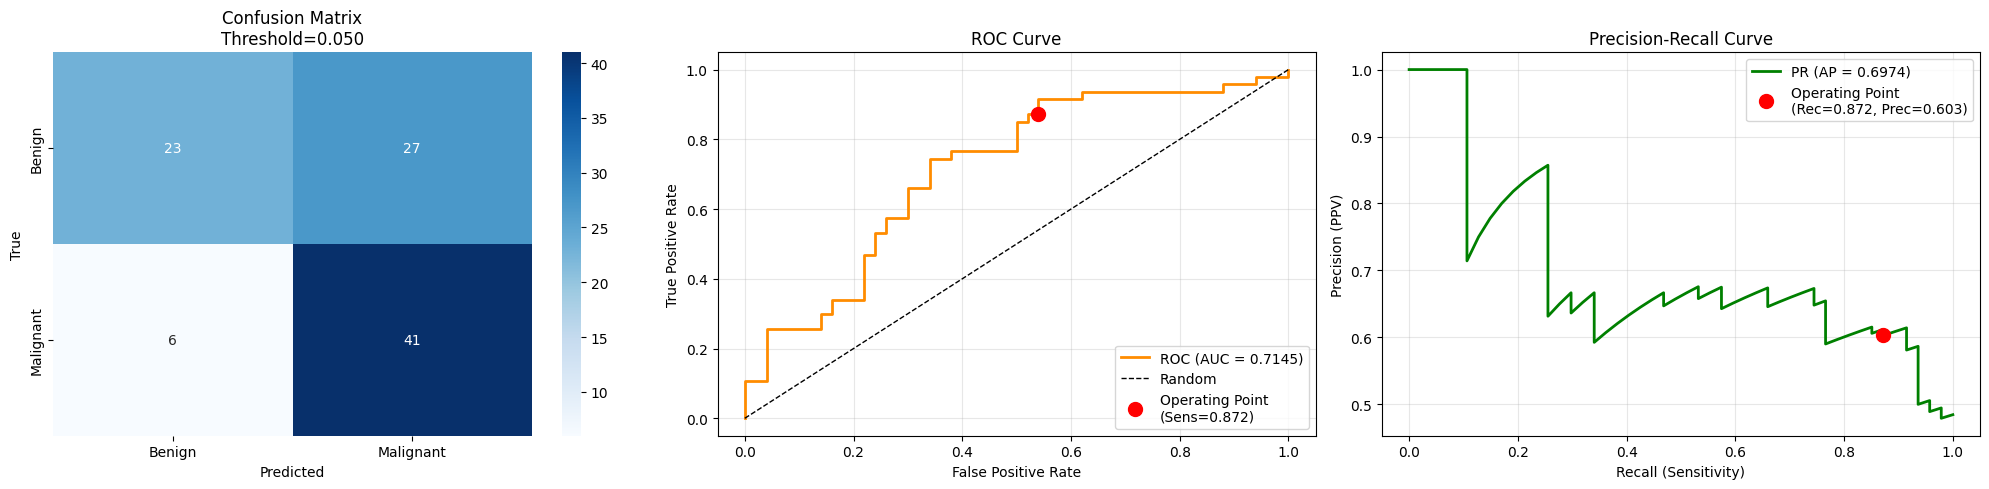

In [12]:
print("\nEvaluating Base model on test set...")

base_test_probs = lr_base.predict_proba(base_test_feats_scaled)[:, 1]

base_results = binary_model_evaluation(
    base_test_labels, base_test_probs, CLASS_NAMES,
    title="DINOv2-Base (ViT-B/14) Zero-Shot — Test Set",
    threshold=None,
    min_sensitivity=MIN_SENSITIVITY_TARGET
)

## 11. Extract Features — DINOv2-Small (ViT-S/14)

In [13]:
print("\n" + "="*70)
print("  DINOv2-SMALL (ViT-S/14) — Feature Extraction")
print("="*70)

small_train_feats, small_train_labels = extract_features(dinov2_small, train_loader, "Small: Train features")
small_val_feats, small_val_labels = extract_features(dinov2_small, val_loader, "Small: Val features")
small_test_feats, small_test_labels = extract_features(dinov2_small, test_loader, "Small: Test features")

print(f"\n✓ Small features extracted:")
print(f"  Train: {small_train_feats.shape}")
print(f"  Val:   {small_val_feats.shape}")
print(f"  Test:  {small_test_feats.shape}")


  DINOv2-SMALL (ViT-S/14) — Feature Extraction


Small: Train features:   0%|          | 0/25 [00:00<?, ?it/s]

Small: Val features:   0%|          | 0/4 [00:00<?, ?it/s]

Small: Test features:   0%|          | 0/4 [00:00<?, ?it/s]


✓ Small features extracted:
  Train: (771, 384)
  Val:   (97, 384)
  Test:  (97, 384)


## 12. Train Logistic Regression — DINOv2-Small

In [14]:
# Standardize features
scaler_small = StandardScaler()
small_train_feats_scaled = scaler_small.fit_transform(small_train_feats)
small_val_feats_scaled = scaler_small.transform(small_val_feats)
small_test_feats_scaled = scaler_small.transform(small_test_feats)

print("\nTraining Logistic Regression on Small features...")
lr_small = LogisticRegression(
    max_iter=LR_MAX_ITER,
    C=LR_C,
    class_weight=LR_CLASS_WEIGHT,
    random_state=SEED,
    solver='lbfgs',
    verbose=0
)
lr_small.fit(small_train_feats_scaled, small_train_labels)

print(f"✓ Logistic Regression trained (Small)")
print(f"  Iterations: {lr_small.n_iter_[0]}")
print(f"  Coefficients shape: {lr_small.coef_.shape}")


Training Logistic Regression on Small features...
✓ Logistic Regression trained (Small)
  Iterations: 131
  Coefficients shape: (1, 384)


## 13. Evaluate DINOv2-Small on Test Set


Evaluating Small model on test set...

🎯 Optimal threshold for ≥95% sensitivity: 0.050
   At this threshold: Sensitivity=0.8723, Specificity=0.3200

  DINOv2-Small (ViT-S/14) Zero-Shot — Test Set
  Classification Threshold: 0.050

  SENSITIVITY METRICS (Malignant Detection):
    Sensitivity (Recall):  0.8723 ✗
    PPV (Precision):       0.5467
    F2 Score:              0.7795

  OVERALL METRICS:
    Accuracy:              0.5876
    Specificity:           0.3200
    NPV:                   0.7273
    F1 Score:              0.6721
    AUC-ROC:               0.6923
    AUC-PR:                0.6427

  Confusion Matrix:
    TN=16   FP=34  
    FN=6    TP=41  

              precision    recall  f1-score   support

      Benign       0.73      0.32      0.44        50
   Malignant       0.55      0.87      0.67        47

    accuracy                           0.59        97
   macro avg       0.64      0.60      0.56        97
weighted avg       0.64      0.59      0.55        97



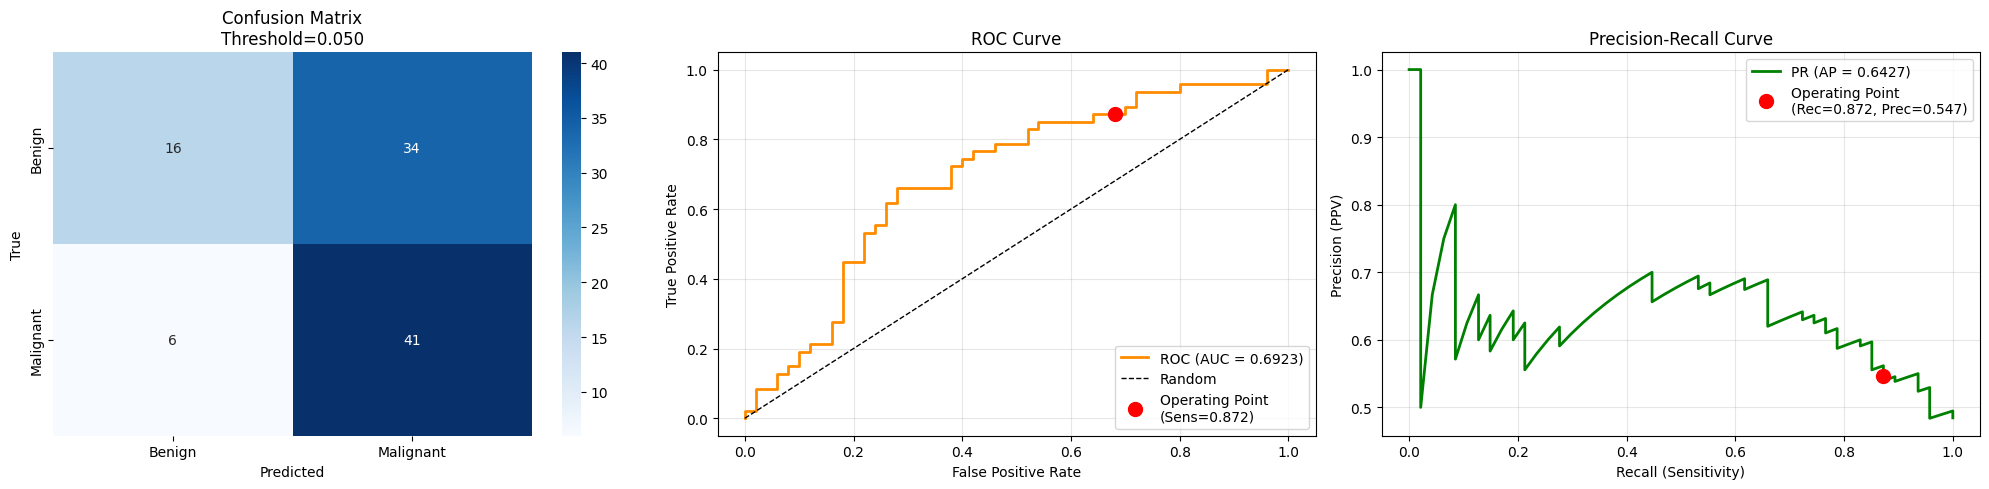

In [15]:
print("\nEvaluating Small model on test set...")

small_test_probs = lr_small.predict_proba(small_test_feats_scaled)[:, 1]

small_results = binary_model_evaluation(
    small_test_labels, small_test_probs, CLASS_NAMES,
    title="DINOv2-Small (ViT-S/14) Zero-Shot — Test Set",
    threshold=None,
    min_sensitivity=MIN_SENSITIVITY_TARGET
)

## 14. Comparison: Base vs Small

In [16]:
print("\n" + "="*80)
print("ZERO-SHOT BASELINE COMPARISON: DINOv2-Base vs DINOv2-Small")
print("="*80)

comparison_df = pd.DataFrame({
    'Metric': ['AUC-ROC', 'AUC-PR', 'Sensitivity', 'Specificity', 'Accuracy', 'F1', 'F2', 'PPV', 'NPV'],
    'Base (ViT-B/14)': [
        base_results['auc_roc'],
        base_results['auc_pr'],
        base_results['sensitivity'],
        base_results['specificity'],
        base_results['accuracy'],
        base_results['f1'],
        base_results['f2'],
        base_results['ppv'],
        base_results['npv'],
    ],
    'Small (ViT-S/14)': [
        small_results['auc_roc'],
        small_results['auc_pr'],
        small_results['sensitivity'],
        small_results['specificity'],
        small_results['accuracy'],
        small_results['f1'],
        small_results['f2'],
        small_results['ppv'],
        small_results['npv'],
    ],
})

comparison_df['Difference (B-S)'] = comparison_df['Base (ViT-B/14)'] - comparison_df['Small (ViT-S/14)']

print("\n" + comparison_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

print(f"\n\nKey Findings:")
if base_results['auc_roc'] > small_results['auc_roc']:
    print(f"  • Base performs better: AUC-ROC {base_results['auc_roc']:.4f} vs {small_results['auc_roc']:.4f} (+{base_results['auc_roc'] - small_results['auc_roc']:.4f})")
else:
    print(f"  • Small performs better: AUC-ROC {small_results['auc_roc']:.4f} vs {base_results['auc_roc']:.4f} (+{small_results['auc_roc'] - base_results['auc_roc']:.4f})")

if base_results['sensitivity'] > small_results['sensitivity']:
    print(f"  • Base more sensitive: {base_results['sensitivity']:.4f} vs {small_results['sensitivity']:.4f} (+{base_results['sensitivity'] - small_results['sensitivity']:.4f})")
else:
    print(f"  • Small more sensitive: {small_results['sensitivity']:.4f} vs {base_results['sensitivity']:.4f} (+{small_results['sensitivity'] - base_results['sensitivity']:.4f})")

print(f"\n  • Base embed dim: {embed_dim_base} (86M backbone params)")
print(f"  • Small embed dim: {embed_dim_small} (22M backbone params)")
print(f"  • Both used identical splits, transforms, and LogReg config")

print("\n" + "="*80)


ZERO-SHOT BASELINE COMPARISON: DINOv2-Base vs DINOv2-Small

     Metric  Base (ViT-B/14)  Small (ViT-S/14)  Difference (B-S)
    AUC-ROC           0.7145            0.6923            0.0221
     AUC-PR           0.6974            0.6427            0.0547
Sensitivity           0.8723            0.8723            0.0000
Specificity           0.4600            0.3200            0.1400
   Accuracy           0.6598            0.5876            0.0722
         F1           0.7130            0.6721            0.0409
         F2           0.8008            0.7795            0.0213
        PPV           0.6029            0.5467            0.0563
        NPV           0.7931            0.7273            0.0658


Key Findings:
  • Base performs better: AUC-ROC 0.7145 vs 0.6923 (+0.0221)
  • Small more sensitive: 0.8723 vs 0.8723 (+0.0000)

  • Base embed dim: 768 (86M backbone params)
  • Small embed dim: 384 (22M backbone params)
  • Both used identical splits, transforms, and LogReg config



## 15. Visualize Comparison

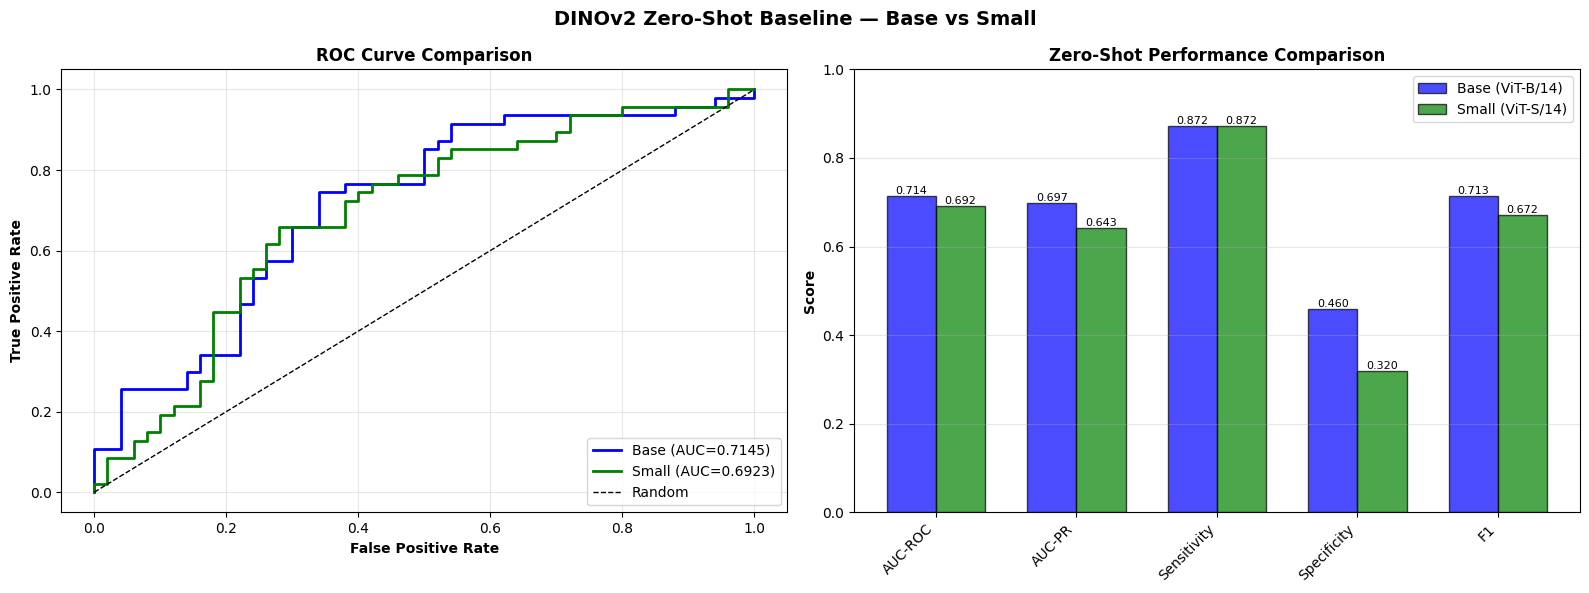

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC comparison
fpr_base, tpr_base, _ = roc_curve(base_test_labels, base_test_probs)
fpr_small, tpr_small, _ = roc_curve(small_test_labels, small_test_probs)

axes[0].plot(fpr_base, tpr_base, lw=2, color='blue',
            label=f'Base (AUC={base_results["auc_roc"]:.4f})')
axes[0].plot(fpr_small, tpr_small, lw=2, color='green',
            label=f'Small (AUC={small_results["auc_roc"]:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[0].set_xlabel('False Positive Rate', fontweight='bold')
axes[0].set_ylabel('True Positive Rate', fontweight='bold')
axes[0].set_title('ROC Curve Comparison', fontweight='bold', fontsize=12)
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Metrics bar chart
metrics = ['AUC-ROC', 'AUC-PR', 'Sensitivity', 'Specificity', 'F1']
base_vals = [base_results['auc_roc'], base_results['auc_pr'],
            base_results['sensitivity'], base_results['specificity'], base_results['f1']]
small_vals = [small_results['auc_roc'], small_results['auc_pr'],
             small_results['sensitivity'], small_results['specificity'], small_results['f1']]

x = np.arange(len(metrics))
width = 0.35

bars1 = axes[1].bar(x - width/2, base_vals, width, label='Base (ViT-B/14)',
                   color='blue', alpha=0.7, edgecolor='black')
bars2 = axes[1].bar(x + width/2, small_vals, width, label='Small (ViT-S/14)',
                   color='green', alpha=0.7, edgecolor='black')

axes[1].set_ylabel('Score', fontweight='bold')
axes[1].set_title('Zero-Shot Performance Comparison', fontweight='bold', fontsize=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics, rotation=45, ha='right')
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')
axes[1].set_ylim([0, 1])

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('DINOv2 Zero-Shot Baseline — Base vs Small', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 16. Results Summary

In [ ]:
summary_df = pd.DataFrame([
    {'Model': 'Base (ViT-B/14)', **base_results},
    {'Model': 'Small (ViT-S/14)', **small_results},
])

print("\n" + "="*80)
print("FINAL RESULTS SUMMARY")
print("="*80)
print(summary_df.to_string(index=False, float_format=lambda x: f'{x:.4f}' if isinstance(x, float) else str(x)))

print(f"\n\n✓ Zero-shot baseline established")
print(f"\nNext steps:")
print(f"  1. Compare these zero-shot results with fine-tuned models")
print(f"  2. Calculate improvement from fine-tuning: (fine-tuned_AUC - zero-shot_AUC)")
print(f"  3. If fine-tuning improves significantly → domain adaptation is critical")
print(f"  4. If zero-shot is competitive → DINOv2 features already work well")

print(f"\n{'='*80}")
print("EXPERIMENT COMPLETE")
print(f"{'='*80}")


FINAL RESULTS SUMMARY
           Model  threshold  accuracy  precision  recall  sensitivity  specificity    ppv    npv     f1     f2  auc_roc  auc_pr  tp  tn  fp  fn
 Base (ViT-B/14)     0.0500    0.6598     0.6029  0.8723       0.8723       0.4600 0.6029 0.7931 0.7130 0.8008   0.7145  0.6974  41  23  27   6
Small (ViT-S/14)     0.0500    0.5876     0.5467  0.8723       0.8723       0.3200 0.5467 0.7273 0.6721 0.7795   0.6923  0.6427  41  16  34   6


✓ Zero-shot baseline established

Next steps:
  1. Compare these zero-shot results with fine-tuned models
  2. Calculate improvement from fine-tuning: (fine-tuned_AUC - zero-shot_AUC)
  3. If fine-tuning improves significantly → domain adaptation is critical
  4. If zero-shot is competitive → DINOv2 features already work well

EXPERIMENT COMPLETE
